# MWE 03 — Optional PyVista visualization

Demonstrates `voids.visualization.pyvista`. If PyVista is unavailable, a Matplotlib fallback is used.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from voids.core.network import Network
from voids.core.sample import SampleGeometry
from voids.paths import notebooks_path

notebooks_dir = notebooks_path()

In [2]:
pore_coords = np.array(
    [[0, 0, 0], [1, 0, 0], [2, 0, 0], [1, 1, 0], [1, -1, 0], [2, 1, 0]], dtype=float
)
throat_conns = np.array([[0, 1], [1, 2], [1, 3], [1, 4], [2, 5]], dtype=int)
net = Network(
    throat_conns=throat_conns,
    pore_coords=pore_coords,
    sample=SampleGeometry(
        bulk_volume=20.0, lengths={"x": 2.0}, cross_sections={"x": 1.0}
    ),
    pore={
        "volume": np.ones(len(pore_coords)),
        "pressure_demo": np.linspace(1, 0, len(pore_coords)),
    },
    throat={
        "length": np.ones(len(throat_conns)),
        "diameter_inscribed": np.linspace(0.2, 0.4, len(throat_conns)),
    },
)

In [3]:
try:
    from voids.visualization.pyvista import plot_network_pyvista

    pl, poly = plot_network_pyvista(
        net,
        point_scalars="pressure_demo",
        cell_scalars="diameter_inscribed",
        render_tubes=False,
        off_screen=True,
        notebook=True,
    )
    print(poly)
    out = notebooks_dir / "pyvista_network.png"
    pl.screenshot(str(out))
    pl.close()
    print("Saved", out)
except ImportError as exc:
    print(exc)
    import matplotlib.pyplot as plt

    fig = plt.figure(figsize=(5, 4))
    ax = fig.add_subplot(projection="3d")
    for i, j in throat_conns:
        ax.plot(*zip(pore_coords[i], pore_coords[j]), linewidth=2)
    ax.scatter(pore_coords[:, 0], pore_coords[:, 1], pore_coords[:, 2], s=40)
    ax.set_title("Fallback visualization")
    plt.show()

PolyData (0x16e8fa020)
  N Cells:    5
  N Points:   6
  N Strips:   0
  X Bounds:   0.000e+00, 2.000e+00
  Y Bounds:   -1.000e+00, 1.000e+00
  Z Bounds:   0.000e+00, 0.000e+00
  N Arrays:   8


Saved /Users/dtvolpatto/Work/voids/notebooks/pyvista_network.png


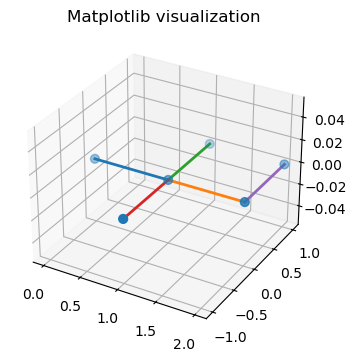

In [ ]:
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(projection="3d")
for i, j in throat_conns:
    ax.plot(*zip(pore_coords[i], pore_coords[j]), linewidth=2)
ax.scatter(pore_coords[:, 0], pore_coords[:, 1], pore_coords[:, 2], s=40)
ax.set_title("Matplotlib visualization")

plt.show()